# Power BI Usage Intelligence: Forecasting Baseline

This notebook is the forecasting step in the project pipeline. It runs after the raw-data, semantic-model, validation, and feature-engineering notebooks have created processed CSV tables.

Primary input: `data/processed/mart_forecast_features.csv`

The existing forecasting logic is preserved where possible:
- Data sufficiency checks
- Naive and seasonal-naive baselines
- Per-report Auto-ARIMA modelling
- Evaluation metrics
- Forecast and metrics output tables


## Run Checklist

1. Run the upstream notebooks/scripts through feature engineering.
2. Confirm `data/processed/mart_forecast_features.csv` exists, or that a report-level daily fallback table exists in `data/processed/`.
3. Run all cells in this notebook in order.
4. Review forecast outputs in `outputs/forecasts/` and metrics outputs in `outputs/metrics/`.


In [1]:
import os
import uuid
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima


In [2]:
# -----------------------------
# Configuration
# -----------------------------
# Internal column names used by the existing forecasting functions.
DATE_COL = "Date"
REPORT_ID_COL = "Report Guid"
REPORT_NAME_COL = "Report Name"
USER_COL = "User Id"
VIEWS_COL = "Occurrences"

# Standard processed feature columns expected from Notebook 04.
STANDARD_DATE_COL = "date"
STANDARD_REPORT_ID_COL = "report_id"
STANDARD_TARGET_COL = "daily_views"
REQUIRED_FEATURE_COLUMNS = {STANDARD_DATE_COL, STANDARD_REPORT_ID_COL, STANDARD_TARGET_COL}

M = 7  # weekly seasonality for SARIMA
SEASONALITY_DAYS = 7

# Data sufficiency criteria
MIN_DAYS = 90
MIN_NONZERO_DAYS = 35
MIN_NONZERO_RATIO = 0.25
MIN_TOTAL_VIEWS = 120

# Model criteria
TRAIN_TEST_FRACTION = 0.8
FORECAST_HORIZON_DAYS = 30
MAX_MAE_RATIO_TO_MEAN = 0.6
MIN_IMPROVEMENT_VS_NAIVE = 0.10
MIN_IMPROVEMENT_VS_SEASONAL_NAIVE = 0.10

# Optional report filter. Use set() for all reports.
ALLOWED_REPORT_NAMES = set()

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURE_INPUT_FILE = PROCESSED_DIR / "mart_forecast_features.csv"
REPORT_DIM_FILE = PROCESSED_DIR / "dim_report.csv"
DATE_DIM_FILE = PROCESSED_DIR / "dim_date.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FORECAST_OUTPUT_DIR = OUTPUT_DIR / "forecasts"
METRICS_OUTPUT_DIR = OUTPUT_DIR / "metrics"
FORECAST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LATEST_FORECAST_FILE = FORECAST_OUTPUT_DIR / "report_view_forecasts_latest.csv"
LATEST_METRICS_FILE = METRICS_OUTPUT_DIR / "report_view_metrics_latest.csv"
FORECASTS_HISTORY_FILE = FORECAST_OUTPUT_DIR / "forecasts_history.csv"
METRICS_HISTORY_FILE = METRICS_OUTPUT_DIR / "metrics_history.csv"
REALIZED_ERRORS_FILE = METRICS_OUTPUT_DIR / "realized_errors_history.csv"

RUN_TIMESTAMP = pd.Timestamp.now()
RUN_ID = RUN_TIMESTAMP.strftime("%Y%m%d_%H%M%S") + "_" + str(uuid.uuid4())[:8]
MODEL_NAME = "AutoARIMA_m7_daily_report_views"

print(f"RUN_ID: {RUN_ID}")
print(f"RUN_TIMESTAMP: {RUN_TIMESTAMP}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")
print(f"PREFERRED_FEATURE_INPUT_FILE: {FEATURE_INPUT_FILE.resolve()}")
print(f"FORECAST_OUTPUT_DIR: {FORECAST_OUTPUT_DIR.resolve()}")
print(f"METRICS_OUTPUT_DIR: {METRICS_OUTPUT_DIR.resolve()}")


RUN_ID: 20260502_192243_c27c9a9e
RUN_TIMESTAMP: 2026-05-02 19:22:43.515722
PROCESSED_DIR: /Users/masegomodibane/Documents/GitHub/Data Science Projects /Forecasting Report Usage/GitHub Final Version/report-usage-forecasting/data/processed
PREFERRED_FEATURE_INPUT_FILE: /Users/masegomodibane/Documents/GitHub/Data Science Projects /Forecasting Report Usage/GitHub Final Version/report-usage-forecasting/data/processed/mart_forecast_features.csv
FORECAST_OUTPUT_DIR: /Users/masegomodibane/Documents/GitHub/Data Science Projects /Forecasting Report Usage/GitHub Final Version/report-usage-forecasting/outputs/forecasts
METRICS_OUTPUT_DIR: /Users/masegomodibane/Documents/GitHub/Data Science Projects /Forecasting Report Usage/GitHub Final Version/report-usage-forecasting/outputs/metrics


## 1) Load Processed Feature Table

The active forecasting input is the processed feature mart produced by the feature-engineering step. The synthetic generator below is retained only as fallback/demo logic and is not used when processed CSV inputs are available.


In [3]:
def generate_synthetic_report_usage(
    n_reports: int = 12,
    start_date: str = "2024-01-01",
    end_date: str = "2025-12-31",
    random_seed: int = 42,
) -> pd.DataFrame:
    """Generate demo-only usage data if no processed CSV inputs are available."""
    rng = np.random.default_rng(random_seed)

    date_index = pd.date_range(start=start_date, end=end_date, freq="D")
    report_ids = [f"RPT-{i:03d}" for i in range(1, n_reports + 1)]
    report_names = [f"Operations Usage Report {i:02d}" for i in range(1, n_reports + 1)]

    rows = []
    for rid, rname in zip(report_ids, report_names):
        base_level = rng.uniform(8, 120)
        trend = rng.uniform(-0.03, 0.08)
        noise_scale = rng.uniform(2, 15)
        zero_day_prob = rng.uniform(0.02, 0.18)

        # Weekly profile (Mon..Sun)
        weekly_profile = np.array([1.25, 1.20, 1.15, 1.10, 1.00, 0.55, 0.45])
        weekly_profile = weekly_profile * rng.uniform(0.85, 1.20)

        for day_number, dt in enumerate(date_index):
            weekday_factor = weekly_profile[dt.weekday()]
            trend_factor = max(0.2, 1 + trend * day_number / 365)
            expected = base_level * weekday_factor * trend_factor
            noisy_expected = max(0, expected + rng.normal(0, noise_scale))

            if rng.uniform(0, 1) < zero_day_prob:
                total_views = 0
            else:
                total_views = int(rng.poisson(max(0.1, noisy_expected)))

            if total_views == 0:
                # Keep occasional explicit zero rows so gaps are not the only source of zeros.
                if rng.uniform(0, 1) < 0.15:
                    rows.append(
                        {
                            DATE_COL: dt,
                            REPORT_ID_COL: rid,
                            REPORT_NAME_COL: rname,
                            USER_COL: f"U{rng.integers(1, 300):04d}",
                            VIEWS_COL: 0,
                        }
                    )
                continue

            # Split daily total into user-level rows so grouping logic is realistic.
            n_users = int(np.clip(rng.poisson(lam=max(1, np.sqrt(total_views))), 1, 80))
            shares = rng.dirichlet(np.ones(n_users))
            user_counts = np.maximum(1, np.round(shares * total_views).astype(int))

            drift = total_views - int(user_counts.sum())
            if drift != 0:
                user_counts[0] += drift
                if user_counts[0] < 1:
                    user_counts[0] = 1

            for count in user_counts:
                rows.append(
                    {
                        DATE_COL: dt,
                        REPORT_ID_COL: rid,
                        REPORT_NAME_COL: rname,
                        USER_COL: f"U{rng.integers(1, 300):04d}",
                        VIEWS_COL: int(max(0, count)),
                    }
                )

    df = pd.DataFrame(rows)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    return df.sort_values([DATE_COL, REPORT_ID_COL, USER_COL]).reset_index(drop=True)


def list_processed_csvs(processed_dir: Path = PROCESSED_DIR) -> list[Path]:
    """Return available processed CSV files for transparency and fallback selection."""
    return sorted(processed_dir.glob("*.csv"))


def choose_forecasting_input(processed_dir: Path = PROCESSED_DIR) -> Path:
    """Choose the best available processed report-level daily forecasting input."""
    preferred_candidates = [
        processed_dir / "mart_forecast_features.csv",
        processed_dir / "mart_report_daily_adoption_ts_features.csv",
        processed_dir / "mart_report_daily_adoption.csv",
        processed_dir / "fact_report_views.csv",
    ]

    for candidate in preferred_candidates:
        if candidate.exists():
            return candidate

    available = "\n".join(str(path) for path in list_processed_csvs(processed_dir)) or "No processed CSV files found."
    raise FileNotFoundError(
        "No suitable processed forecasting input was found. "
        "Run the upstream data and feature-engineering notebooks first.\n\n"
        f"Available processed CSVs:\n{available}"
    )


def standardise_forecasting_columns(df: pd.DataFrame, source_path: Path) -> pd.DataFrame:
    """Standardise a processed input table to date, report_id, and daily_views."""
    standardised = df.copy()

    rename_map = {}
    if "Date" in standardised.columns and STANDARD_DATE_COL not in standardised.columns:
        rename_map["Date"] = STANDARD_DATE_COL
    if "Report Guid" in standardised.columns and STANDARD_REPORT_ID_COL not in standardised.columns:
        rename_map["Report Guid"] = STANDARD_REPORT_ID_COL
    if "ReportId" in standardised.columns and STANDARD_REPORT_ID_COL not in standardised.columns:
        rename_map["ReportId"] = STANDARD_REPORT_ID_COL
    if "Occurrences" in standardised.columns and STANDARD_TARGET_COL not in standardised.columns:
        rename_map["Occurrences"] = STANDARD_TARGET_COL
    if "view_count" in standardised.columns and STANDARD_TARGET_COL not in standardised.columns:
        rename_map["view_count"] = STANDARD_TARGET_COL
    if "views" in standardised.columns and STANDARD_TARGET_COL not in standardised.columns:
        rename_map["views"] = STANDARD_TARGET_COL

    if rename_map:
        standardised = standardised.rename(columns=rename_map)

    if STANDARD_DATE_COL not in standardised.columns and "date_key" in standardised.columns:
        if not DATE_DIM_FILE.exists():
            raise FileNotFoundError(
                f"{source_path.name} uses date_key, but {DATE_DIM_FILE} was not found."
            )
        dim_date = pd.read_csv(DATE_DIM_FILE, usecols=["date_key", "date"])
        standardised = standardised.merge(dim_date, on="date_key", how="left")

    missing_columns = REQUIRED_FEATURE_COLUMNS - set(standardised.columns)
    if missing_columns:
        raise ValueError(
            f"{source_path.name} is missing required forecasting columns after standardisation: "
            f"{sorted(missing_columns)}"
        )

    standardised = standardised[[STANDARD_DATE_COL, STANDARD_REPORT_ID_COL, STANDARD_TARGET_COL]].copy()
    standardised[STANDARD_DATE_COL] = pd.to_datetime(standardised[STANDARD_DATE_COL], errors="coerce")
    standardised[STANDARD_TARGET_COL] = pd.to_numeric(standardised[STANDARD_TARGET_COL], errors="coerce").fillna(0)
    standardised = standardised.dropna(subset=[STANDARD_DATE_COL, STANDARD_REPORT_ID_COL])

    # Fallback fact tables may be user-level; aggregate them to one row per report per day.
    standardised = (
        standardised.groupby([STANDARD_DATE_COL, STANDARD_REPORT_ID_COL], as_index=False)[STANDARD_TARGET_COL]
        .sum()
        .sort_values([STANDARD_DATE_COL, STANDARD_REPORT_ID_COL])
    )

    return standardised


def adapt_to_existing_forecasting_schema(features: pd.DataFrame) -> pd.DataFrame:
    """Map standard processed feature columns into the legacy notebook schema."""
    report_names = pd.DataFrame()
    if REPORT_DIM_FILE.exists():
        report_names = pd.read_csv(REPORT_DIM_FILE, usecols=["report_id", "report_name"])

    model_input = features.copy()
    if not report_names.empty:
        model_input = model_input.merge(report_names, on=STANDARD_REPORT_ID_COL, how="left")
    else:
        model_input["report_name"] = model_input[STANDARD_REPORT_ID_COL]

    model_input["report_name"] = model_input["report_name"].fillna(model_input[STANDARD_REPORT_ID_COL])
    model_input["synthetic_user_id"] = "PROCESSED_DAILY_TOTAL"

    model_input = model_input.rename(
        columns={
            STANDARD_DATE_COL: DATE_COL,
            STANDARD_REPORT_ID_COL: REPORT_ID_COL,
            "report_name": REPORT_NAME_COL,
            STANDARD_TARGET_COL: VIEWS_COL,
            "synthetic_user_id": USER_COL,
        }
    )

    model_input[VIEWS_COL] = pd.to_numeric(model_input[VIEWS_COL], errors="coerce").fillna(0)
    model_input[DATE_COL] = pd.to_datetime(model_input[DATE_COL])

    return model_input[[DATE_COL, REPORT_ID_COL, REPORT_NAME_COL, USER_COL, VIEWS_COL]].sort_values(
        [DATE_COL, REPORT_ID_COL]
    ).reset_index(drop=True)


def load_forecast_feature_input() -> tuple[pd.DataFrame, pd.DataFrame, Path]:
    """Load processed forecasting input and return standard plus modelling schemas."""
    input_path = choose_forecasting_input()
    processed_csvs = list_processed_csvs()
    print("Available processed CSV files:")
    for csv_path in processed_csvs:
        print(f"- {csv_path.relative_to(PROJECT_ROOT)}")

    features_raw = pd.read_csv(input_path)
    forecast_features = standardise_forecasting_columns(features_raw, input_path)
    model_input = adapt_to_existing_forecasting_schema(forecast_features)

    missing_columns = REQUIRED_FEATURE_COLUMNS - set(forecast_features.columns)
    if missing_columns:
        raise ValueError(f"Standardised forecast input is missing: {sorted(missing_columns)}")

    return forecast_features, model_input, input_path


forecast_features_df, report_views_df, ACTIVE_FORECAST_INPUT_FILE = load_forecast_feature_input()
print(f"Loaded forecasting input from: {ACTIVE_FORECAST_INPUT_FILE.relative_to(PROJECT_ROOT)}")
print("Standardised columns:", list(forecast_features_df.columns))
print("Model input shape:", report_views_df.shape)
forecast_features_df.head()


Available processed CSV files:
- data/processed/dim_date.csv
- data/processed/dim_page.csv
- data/processed/dim_report.csv
- data/processed/dim_user.csv
- data/processed/fact_page_views.csv
- data/processed/fact_report_loads.csv
- data/processed/fact_report_views.csv
- data/processed/mart_forecast_features.csv
- data/processed/mart_report_daily_adoption.csv
- data/processed/mart_report_daily_adoption_ts_features.csv
- data/processed/mart_report_performance.csv
- data/processed/mart_user_engagement.csv
Loaded forecasting input from: data/processed/mart_forecast_features.csv
Standardised columns: ['date', 'report_id', 'daily_views']
Model input shape: (13650, 5)


,date,report_id,daily_views
0,2025-01-01,R_001,36
1,2025-01-01,R_002,80
2,2025-01-01,R_003,27
3,2025-01-01,R_004,34
4,2025-01-01,R_005,88


In [4]:
# Quick EDA snapshot
summary = (
    report_views_df.groupby(REPORT_NAME_COL)[VIEWS_COL]
    .agg(total_views="sum", rows="count", avg_occurrence_per_row="mean")
    .sort_values("total_views", ascending=False)
)
summary.head(10)


,total_views,rows,avg_occurrence_per_row
Report Name,,,
Report_022,62683,455,137.764835
Report_027,44476,455,97.749451
Report_025,39139,455,86.019780
Report_008,35878,455,78.852747
Report_005,35451,455,77.914286
Report_026,32048,455,70.435165
Report_016,25643,455,56.358242
Report_002,24635,455,54.142857
Report_006,24610,455,54.087912


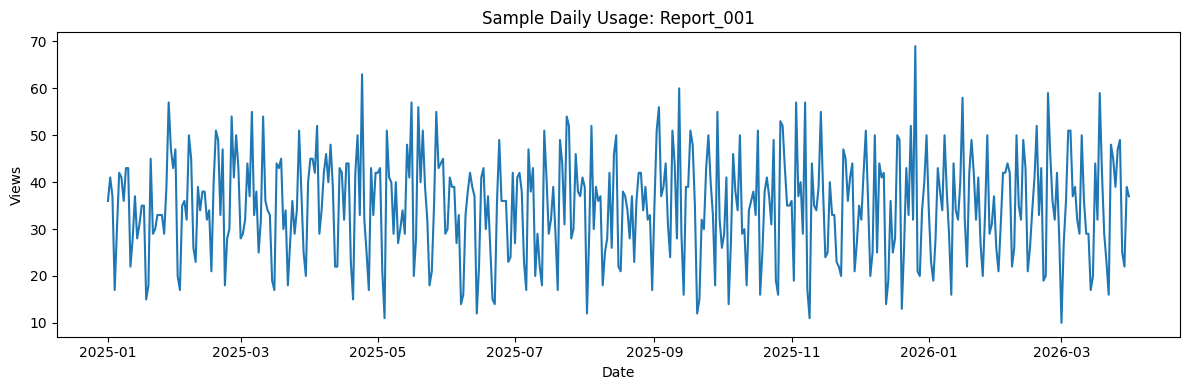

In [5]:
# Plot one sample report's daily total behaviour
sample_report = report_views_df[REPORT_NAME_COL].iloc[0]
daily_sample = (
    report_views_df[report_views_df[REPORT_NAME_COL] == sample_report]
    .groupby(DATE_COL)[VIEWS_COL]
    .sum()
)

plt.figure(figsize=(12, 4))
plt.plot(daily_sample.index, daily_sample.values)
plt.title(f"Sample Daily Usage: {sample_report}")
plt.xlabel("Date")
plt.ylabel("Views")
plt.tight_layout()
plt.show()


## 2) Validate Required Fields and Run Data Quality Checks

The processed input is standardised to the forecasting fields `date`, `report_id`, and `daily_views`, then adapted into the legacy column names used by the existing modelling functions.


In [6]:
def run_data_quality_checks(df: pd.DataFrame) -> pd.DataFrame:
    checks = []

    checks.append({"check": "row_count", "value": len(df), "status": "ok" if len(df) > 0 else "fail"})

    for col in [DATE_COL, REPORT_ID_COL, REPORT_NAME_COL, USER_COL, VIEWS_COL]:
        null_count = int(df[col].isna().sum())
        checks.append(
            {
                "check": f"nulls_{col}",
                "value": null_count,
                "status": "ok" if null_count == 0 else "warn",
            }
        )

    duplicate_key_count = int(
        df.duplicated(subset=[DATE_COL, REPORT_ID_COL, REPORT_NAME_COL, USER_COL, VIEWS_COL]).sum()
    )
    checks.append(
        {
            "check": "exact_duplicate_rows",
            "value": duplicate_key_count,
            "status": "ok" if duplicate_key_count == 0 else "warn",
        }
    )

    min_date = df[DATE_COL].min()
    max_date = df[DATE_COL].max()
    checks.append({"check": "min_date", "value": str(min_date.date()), "status": "ok"})
    checks.append({"check": "max_date", "value": str(max_date.date()), "status": "ok"})

    negative_occurrences = int((df[VIEWS_COL] < 0).sum())
    checks.append(
        {
            "check": "negative_occurrences",
            "value": negative_occurrences,
            "status": "ok" if negative_occurrences == 0 else "fail",
        }
    )

    return pd.DataFrame(checks)


dq = run_data_quality_checks(report_views_df)
dq


,check,value,status
0,row_count,13650,ok
1,nulls_Date,0,ok
2,nulls_Report Guid,0,ok
3,nulls_Report Name,0,ok
4,nulls_User Id,0,ok
5,nulls_Occurrences,0,ok
6,exact_duplicate_rows,0,ok
7,min_date,2025-01-01,ok
8,max_date,2026-03-31,ok
9,negative_occurrences,0,ok


## 3) Select Report Series and Build Daily Time Series

In [7]:
def build_daily_series_for_all_reports(
    df: pd.DataFrame,
    report_id_col: str = REPORT_ID_COL,
    date_col: str = DATE_COL,
) -> Tuple[Dict[str, pd.Series], Dict[str, str]]:
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    if VIEWS_COL not in d.columns:
        raise KeyError(f"Expected column '{VIEWS_COL}' is missing")

    d[VIEWS_COL] = pd.to_numeric(d[VIEWS_COL], errors="coerce").fillna(0)

    series_dict: Dict[str, pd.Series] = {}
    name_lookup: Dict[str, str] = {}

    for rid, g in d.groupby(report_id_col):
        report_name = g[REPORT_NAME_COL].iloc[0]
        name_lookup[rid] = report_name

        daily = (
            g.groupby(date_col)[VIEWS_COL]
            .sum()
            .rename("Views")
            .sort_index()
        )

        full_index = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
        daily_full = daily.reindex(full_index, fill_value=0)
        daily_full.index.name = date_col

        series_dict[rid] = daily_full

    return series_dict, name_lookup


## 4) Data Sufficiency Checks

In [8]:
def filter_by_data_criteria(
    series_dict: Dict[str, pd.Series],
    min_days: int = MIN_DAYS,
    min_nonzero_days: int = MIN_NONZERO_DAYS,
    min_nonzero_ratio: float = MIN_NONZERO_RATIO,
    min_total_views: int = MIN_TOTAL_VIEWS,
) -> Tuple[List[str], pd.DataFrame]:
    records = []
    passing: List[str] = []

    for rid, s in series_dict.items():
        total_days = int(s.size)
        nonzero_days = int((s > 0).sum())
        nonzero_ratio = nonzero_days / total_days if total_days else 0.0
        total_views = int(s.sum())

        passes = (
            total_days >= min_days
            and nonzero_days >= min_nonzero_days
            and nonzero_ratio >= min_nonzero_ratio
            and total_views >= min_total_views
        )

        records.append(
            {
                "report_id": rid,
                "total_days": total_days,
                "nonzero_days": nonzero_days,
                "nonzero_ratio": nonzero_ratio,
                "total_views": total_views,
                "passes_data_criteria": passes,
            }
        )
        if passes:
            passing.append(rid)

    return passing, pd.DataFrame.from_records(records)


## 5) Baseline and ARIMA Forecasting Logic

In [9]:
def naive_forecast_last_value(y_train: pd.Series, steps: int) -> np.ndarray:
    return np.full(shape=steps, fill_value=float(y_train.iloc[-1]), dtype=float)


def seasonal_naive_forecast(
    y_train: pd.Series,
    steps: int,
    season_length: int = SEASONALITY_DAYS,
) -> np.ndarray:
    if len(y_train) < season_length:
        return naive_forecast_last_value(y_train, steps)
    last_season = y_train.iloc[-season_length:].to_numpy(dtype=float)
    repeats = int(np.ceil(steps / season_length))
    return np.tile(last_season, repeats)[:steps]


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom


def train_and_evaluate_arima(
    y: pd.Series,
    train_fraction: float = TRAIN_TEST_FRACTION,
    horizon_days: int = FORECAST_HORIZON_DAYS,
) -> Tuple[object, pd.DataFrame, dict]:
    y = y.astype(float)
    n = len(y)
    train_size = int(n * train_fraction)

    if train_size < 30 or n - train_size < 7:
        raise ValueError("Series too short for robust backtest split")

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    model = auto_arima(
        y_train,
        seasonal=True,
        m=M,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
    )

    n_test = len(y_test)
    fc_test, conf_test = model.predict(n_periods=n_test, return_conf_int=True)

    # Non-negative clipping for count data
    fc_test = np.clip(fc_test, 0, None)
    conf_test = np.clip(np.asarray(conf_test, dtype=float), 0, None)

    backtest_df = pd.DataFrame(
        {
            "forecast": fc_test,
            "lower_ci": conf_test[:, 0],
            "upper_ci": conf_test[:, 1],
            "actual": y_test.values,
        },
        index=y_test.index,
    )

    backtest_df["error"] = backtest_df["actual"] - backtest_df["forecast"]
    backtest_df["abs_error"] = backtest_df["error"].abs()
    backtest_df["pct_error"] = (
        backtest_df["abs_error"] / backtest_df["actual"].replace(0, np.nan)
    ) * 100

    mae_arima = mean_absolute_error(y_test, fc_test)
    rmse_arima = np.sqrt(mean_squared_error(y_test, fc_test))
    wape_arima = wape(y_test.to_numpy(), fc_test)
    avg_level = y_test.mean()

    naive_fc = naive_forecast_last_value(y_train, n_test)
    seasonal_naive_fc = seasonal_naive_forecast(y_train, n_test)

    mae_naive = mean_absolute_error(y_test, naive_fc)
    rmse_naive = np.sqrt(mean_squared_error(y_test, naive_fc))
    wape_naive = wape(y_test.to_numpy(), naive_fc)

    mae_seasonal_naive = mean_absolute_error(y_test, seasonal_naive_fc)
    rmse_seasonal_naive = np.sqrt(mean_squared_error(y_test, seasonal_naive_fc))
    wape_seasonal_naive = wape(y_test.to_numpy(), seasonal_naive_fc)

    model.update(y_test)
    fc_future, conf_future = model.predict(n_periods=horizon_days, return_conf_int=True)

    # Non-negative clipping for count data
    fc_future = np.clip(fc_future, 0, None)
    conf_future = np.clip(np.asarray(conf_future, dtype=float), 0, None)

    future_dates = pd.date_range(
        start=y.index[-1] + pd.Timedelta(days=1), periods=horizon_days, freq="D"
    )

    future_df = pd.DataFrame(
        {
            "forecast": fc_future,
            "lower_ci": conf_future[:, 0],
            "upper_ci": conf_future[:, 1],
            "actual": np.nan,
            "error": np.nan,
            "abs_error": np.nan,
            "pct_error": np.nan,
        },
        index=future_dates,
    )

    combined_forecast = pd.concat([backtest_df, future_df])
    combined_forecast.index.name = DATE_COL

    p, d, q = model.order
    P, D, Q, m = model.seasonal_order

    metrics = {
        "n_obs": n,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "mae_arima": mae_arima,
        "rmse_arima": rmse_arima,
        "wape_arima": wape_arima,
        "mae_naive": mae_naive,
        "rmse_naive": rmse_naive,
        "wape_naive": wape_naive,
        "mae_seasonal_naive": mae_seasonal_naive,
        "rmse_seasonal_naive": rmse_seasonal_naive,
        "wape_seasonal_naive": wape_seasonal_naive,
        "mae_improvement_vs_naive": 1 - mae_arima / mae_naive if mae_naive > 0 else np.nan,
        "mae_improvement_vs_seasonal_naive": 1 - mae_arima / mae_seasonal_naive if mae_seasonal_naive > 0 else np.nan,
        "avg_level_test": avg_level,
        "p": p,
        "d": d,
        "q": q,
        "P": P,
        "D": D,
        "Q": Q,
        "m": m,
        "model_str": f"ARIMA({p},{d},{q})x({P},{D},{Q},{m})",
    }

    return model, combined_forecast, metrics


def apply_model_criteria(
    metrics: dict,
    max_mae_ratio_to_mean: float = MAX_MAE_RATIO_TO_MEAN,
    min_improvement_vs_naive: float = MIN_IMPROVEMENT_VS_NAIVE,
    min_improvement_vs_seasonal: float = MIN_IMPROVEMENT_VS_SEASONAL_NAIVE,
) -> dict:
    mae = metrics["mae_arima"]
    avg_level = metrics["avg_level_test"]
    mae_naive = metrics["mae_naive"]
    mae_seasonal_naive = metrics["mae_seasonal_naive"]

    cond_mae_ratio = pd.isna(avg_level) or avg_level == 0 or mae <= max_mae_ratio_to_mean * avg_level
    cond_improvement_naive = pd.isna(mae_naive) or mae_naive == 0 or mae <= mae_naive * (1 - min_improvement_vs_naive)
    cond_improvement_seasonal = (
        pd.isna(mae_seasonal_naive)
        or mae_seasonal_naive == 0
        or mae <= mae_seasonal_naive * (1 - min_improvement_vs_seasonal)
    )

    # Consistent rule: require quality + improvement over at least one baseline
    cond_improvement_any = cond_improvement_naive or cond_improvement_seasonal

    metrics["passes_mae_ratio"] = bool(cond_mae_ratio)
    metrics["passes_improvement_vs_naive"] = bool(cond_improvement_naive)
    metrics["passes_improvement_vs_seasonal_naive"] = bool(cond_improvement_seasonal)
    metrics["passes_model_criteria"] = bool(cond_mae_ratio and cond_improvement_any)
    return metrics


## 6) Forecast Pipeline

In [10]:
def run_forecasts_for_reports(raw_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    series_dict, name_lookup = build_daily_series_for_all_reports(raw_df)
    passing_data_ids, data_diag = filter_by_data_criteria(series_dict)

    if ALLOWED_REPORT_NAMES:
        passing_data_ids = [rid for rid in passing_data_ids if name_lookup.get(rid) in ALLOWED_REPORT_NAMES]

    all_forecasts = []
    all_metrics = []

    for rid in passing_data_ids:
        y = series_dict[rid]
        name = name_lookup.get(rid, "")

        try:
            _, combined_forecast, metrics = train_and_evaluate_arima(y)
            metrics = apply_model_criteria(metrics)
        except Exception as exc:
            metrics = {
                "n_obs": len(y),
                "n_train": np.nan,
                "n_test": np.nan,
                "mae_arima": np.nan,
                "rmse_arima": np.nan,
                "wape_arima": np.nan,
                "mae_naive": np.nan,
                "rmse_naive": np.nan,
                "wape_naive": np.nan,
                "mae_seasonal_naive": np.nan,
                "rmse_seasonal_naive": np.nan,
                "wape_seasonal_naive": np.nan,
                "avg_level_test": np.nan,
                "passes_model_criteria": False,
                "error": str(exc),
            }
            combined_forecast = None

        metrics["report_id"] = rid
        metrics["report_name"] = name

        diag_row = data_diag.loc[data_diag["report_id"] == rid].iloc[0]
        metrics.update(diag_row.to_dict())
        all_metrics.append(metrics)

        if combined_forecast is not None and metrics["passes_model_criteria"]:
            df_out = combined_forecast.copy().reset_index()
            df_out["ReportId"] = rid
            df_out["ReportName"] = name
            df_out["IsForecast"] = df_out["actual"].isna().astype(int)
            df_out["ModelRunTimestamp"] = RUN_TIMESTAMP
            df_out["ModelName"] = MODEL_NAME
            df_out["run_id"] = RUN_ID
            df_out["run_timestamp"] = RUN_TIMESTAMP
            df_out["IsPlaceholderRow"] = 0
            all_forecasts.append(df_out)

    forecast_table = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()
    metrics_table = pd.DataFrame(all_metrics)

    return forecast_table, metrics_table, data_diag


## 7) Save Outputs

In [11]:
EXPECTED_FORECAST_COLUMNS = [
    DATE_COL,
    "forecast", "lower_ci", "upper_ci", "actual",
    "error", "abs_error", "pct_error",
    "ReportId", "ReportName", "IsForecast",
    "ModelRunTimestamp", "ModelName", "run_id", "run_timestamp",
    "IsPlaceholderRow",
]


def ensure_forecast_schema(df: pd.DataFrame) -> pd.DataFrame:
    for col in EXPECTED_FORECAST_COLUMNS:
        if col not in df.columns:
            if col == DATE_COL:
                df[col] = pd.NaT
            elif col in {"IsForecast", "IsPlaceholderRow"}:
                df[col] = 0
            elif col in {"ReportId", "ReportName", "ModelName", "run_id"}:
                df[col] = pd.NA
            elif col in {"ModelRunTimestamp", "run_timestamp"}:
                df[col] = pd.NaT
            else:
                df[col] = pd.NA
    return df[EXPECTED_FORECAST_COLUMNS]


def make_placeholder_forecast_row() -> pd.DataFrame:
    row = {
        DATE_COL: pd.Timestamp("1900-01-01"),
        "forecast": pd.NA,
        "lower_ci": pd.NA,
        "upper_ci": pd.NA,
        "actual": pd.NA,
        "error": pd.NA,
        "abs_error": pd.NA,
        "pct_error": pd.NA,
        "ReportId": pd.NA,
        "ReportName": "NO_FORECAST",
        "IsForecast": 1,
        "ModelRunTimestamp": RUN_TIMESTAMP,
        "ModelName": MODEL_NAME,
        "run_id": RUN_ID,
        "run_timestamp": RUN_TIMESTAMP,
        "IsPlaceholderRow": 1,
    }
    return pd.DataFrame([row])[EXPECTED_FORECAST_COLUMNS]


def save_latest_outputs(forecast_table: pd.DataFrame, metrics_table: pd.DataFrame) -> None:
    if forecast_table is None or forecast_table.empty:
        forecast_table = make_placeholder_forecast_row()
    forecast_table = ensure_forecast_schema(forecast_table)

    forecast_table.to_csv(LATEST_FORECAST_FILE, index=False)
    metrics_table.to_csv(LATEST_METRICS_FILE, index=False)
    print(f"Saved latest forecasts to: {LATEST_FORECAST_FILE}")
    print(f"Saved latest metrics to: {LATEST_METRICS_FILE}")


def append_forecasts_history(forecast_table: pd.DataFrame) -> None:
    if forecast_table is None or forecast_table.empty:
        return

    df_future = forecast_table[forecast_table["IsForecast"] == 1].copy()
    if df_future.empty:
        return

    df_future[DATE_COL] = pd.to_datetime(df_future[DATE_COL], errors="coerce")
    df_future["ModelRunTimestamp"] = pd.to_datetime(df_future["ModelRunTimestamp"], errors="coerce")

    df_future["target_date"] = df_future[DATE_COL]
    df_future["horizon_days"] = (
        df_future["target_date"].dt.normalize() - df_future["ModelRunTimestamp"].dt.normalize()
    ).dt.days

    df_out = df_future[[
        "run_id", "run_timestamp", "ReportId", "ReportName", "target_date", "horizon_days",
        "forecast", "lower_ci", "upper_ci", "ModelName"
    ]].rename(columns={
        "ReportId": "report_id",
        "ReportName": "report_name",
        "forecast": "forecast_views",
        "ModelName": "model_name",
    })

    write_header = not FORECASTS_HISTORY_FILE.exists()
    df_out.to_csv(FORECASTS_HISTORY_FILE, mode="a", index=False, header=write_header)
    print(f"Appended forecast history to: {FORECASTS_HISTORY_FILE}")


def append_metrics_history(metrics_table: pd.DataFrame) -> None:
    if metrics_table.empty:
        return
    df = metrics_table.copy()
    df["run_id"] = RUN_ID
    df["run_timestamp"] = RUN_TIMESTAMP

    write_header = not METRICS_HISTORY_FILE.exists()
    df.to_csv(METRICS_HISTORY_FILE, mode="a", index=False, header=write_header)
    print(f"Appended metrics history to: {METRICS_HISTORY_FILE}")


## 8) Evaluation Backfill

In [12]:
def compute_daily_actuals(raw_df: pd.DataFrame) -> pd.DataFrame:
    d = raw_df.copy()
    d[DATE_COL] = pd.to_datetime(d[DATE_COL])
    d[VIEWS_COL] = pd.to_numeric(d[VIEWS_COL], errors="coerce").fillna(0)

    grouped = (
        d.groupby([REPORT_ID_COL, REPORT_NAME_COL, DATE_COL])[VIEWS_COL]
        .sum()
        .reset_index(name="actual_views")
    )

    return grouped.rename(columns={
        REPORT_ID_COL: "report_id",
        REPORT_NAME_COL: "report_name",
        DATE_COL: "date",
    })


def update_realized_errors(raw_df: pd.DataFrame) -> pd.DataFrame:
    if not FORECASTS_HISTORY_FILE.exists():
        return pd.DataFrame()

    forecasts_hist = pd.read_csv(FORECASTS_HISTORY_FILE, parse_dates=["run_timestamp", "target_date"])
    if forecasts_hist.empty:
        return pd.DataFrame()

    actuals = compute_daily_actuals(raw_df)
    actuals["date"] = pd.to_datetime(actuals["date"])
    actuals = actuals[["report_id", "date", "actual_views"]]

    merged = forecasts_hist.merge(
        actuals,
        left_on=["report_id", "target_date"],
        right_on=["report_id", "date"],
        how="left",
    )

    merged = merged[~merged["actual_views"].isna()].copy()
    if merged.empty:
        return pd.DataFrame()

    if REALIZED_ERRORS_FILE.exists():
        existing = pd.read_csv(REALIZED_ERRORS_FILE, parse_dates=["target_date"])
        if not existing.empty:
            existing_keys = set(zip(existing["run_id"], existing["report_id"], existing["target_date"]))
            merged["key"] = list(zip(merged["run_id"], merged["report_id"], merged["target_date"]))
            merged = merged[~merged["key"].isin(existing_keys)].copy()
            merged.drop(columns=["key"], inplace=True)

    if merged.empty:
        return pd.DataFrame()

    merged["error"] = merged["actual_views"] - merged["forecast_views"]
    merged["abs_error"] = merged["error"].abs()
    merged["pct_error"] = (merged["abs_error"] / merged["actual_views"].replace(0, np.nan)) * 100
    merged["realized_at"] = pd.Timestamp.now()

    df_out = merged[[
        "run_id", "report_id", "report_name", "target_date", "horizon_days",
        "forecast_views", "actual_views", "error", "abs_error", "pct_error",
        "run_timestamp", "realized_at", "model_name"
    ]]

    write_header = not REALIZED_ERRORS_FILE.exists()
    df_out.to_csv(REALIZED_ERRORS_FILE, mode="a", index=False, header=write_header)
    return df_out


## 9) Execute Forecasting Pipeline

In [ ]:
forecast_table, metrics_table, data_diag = run_forecasts_for_reports(report_views_df)

save_latest_outputs(forecast_table, metrics_table)
append_forecasts_history(forecast_table)
append_metrics_history(metrics_table)
realized_errors_df = update_realized_errors(report_views_df)

print(f"Input CSV used: {ACTIVE_FORECAST_INPUT_FILE.relative_to(PROJECT_ROOT)}")
print(f"Forecast rows published: {len(forecast_table)}")
print(f"Metrics rows: {len(metrics_table)}")
print(f"Reports passing data criteria: {int(data_diag['passes_data_criteria'].sum())}/{len(data_diag)}")
print(f"Forecast outputs directory: {FORECAST_OUTPUT_DIR}")
print(f"Metrics outputs directory: {METRICS_OUTPUT_DIR}")

metrics_table.head()


In [ ]:
# High-level acceptance view
if not metrics_table.empty:
    cols = [
        "report_name", "passes_data_criteria", "passes_model_criteria",
        "mae_arima", "mae_naive", "mae_seasonal_naive",
        "mae_improvement_vs_naive", "mae_improvement_vs_seasonal_naive",
        "wape_arima", "model_str"
    ]
    display(metrics_table[cols].sort_values(["passes_model_criteria", "mae_arima"], ascending=[False, True]).head(15))


,report_name,passes_data_criteria,passes_model_criteria,mae_arima,mae_naive,mae_seasonal_naive,mae_improvement_vs_naive,mae_improvement_vs_seasonal_naive,wape_arima,model_str
8,Operations Usage Report 09,True,True,5.320836,9.136054,8.176871,0.417600,0.349282,0.335548,"ARIMA(1,0,0)x(1,0,2,7)"
10,Operations Usage Report 11,True,True,7.455375,19.299320,11.619048,0.613698,0.358349,0.464775,"ARIMA(2,0,2)x(1,0,1,7)"
7,Operations Usage Report 08,True,True,13.191881,24.719178,18.678082,0.466330,0.293724,0.533670,"ARIMA(0,0,0)x(1,0,1,7)"
9,Operations Usage Report 10,True,True,14.242373,27.129252,18.020408,0.475018,0.209653,0.197029,"ARIMA(0,0,0)x(2,0,2,7)"
5,Operations Usage Report 06,True,True,29.588801,71.925170,44.374150,0.588617,0.333197,0.411383,"ARIMA(0,0,0)x(1,0,1,7)"
1,Operations Usage Report 02,True,True,35.702671,41.623288,23.280822,0.142243,-0.533566,0.277901,"ARIMA(5,1,0)x(2,0,0,7)"
0,Operations Usage Report 01,True,False,31.895193,31.775510,23.047619,-0.003767,-0.383882,0.427090,"ARIMA(1,0,0)x(1,0,1,7)"
2,Operations Usage Report 03,True,False,39.210583,39.130137,27.753425,-0.002056,-0.412820,0.525447,"ARIMA(5,1,0)x(2,0,0,7)"
6,Operations Usage Report 07,True,False,40.320070,41.326531,24.714286,0.024354,-0.631448,0.354828,"ARIMA(5,1,0)x(2,0,0,7)"
11,Operations Usage Report 12,True,False,40.940671,43.523810,33.911565,0.059350,-0.207278,0.466027,"ARIMA(0,0,0)x(2,0,0,7)"


## 10) Next Steps

This notebook now consumes the processed feature mart and saves outputs into dedicated forecast and metrics folders. Later refactor work can move more stable notebook functions into `src/`, improve backtesting, and tighten evaluation reporting.
